# Installing the dataset

In [ ]:
!pip install kaggle kagglehub

import kagglehub

path = kagglehub.dataset_download("fifthtribe/how-isis-uses-twitter")

print("Path to dataset files:", path)

100%|██████████| 2.37M/2.37M [00:00<00:00, 95.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fifthtribe/how-isis-uses-twitter/versions/2


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


filename = os.path.join(path, 'tweets.csv')

df = pd.read_csv(filename)

df['tweets'] = df['tweets'].str.replace("ENGLISH TRANSLATION:", "", regex=False)
df['links'] = df['tweets'].str.count(r'http')
df['tweets'] = df['tweets'].str.replace(r'http\S+', "", regex=True)

df['ascii_check'] = df['tweets'].apply(lambda x: all(ord(c) < 128 for c in x))
df = df[df['ascii_check'] == True]

In [ ]:
min(df['time'])

'1/1/2016 16:37'

In [ ]:
max(df['time'])

'9/9/2015 6:47'

In [ ]:
len(np.unique(df['username']))

112

# Building the Network
Using reference code from Jiashen Liu on Kaggle

In [ ]:
# Creating the network table


mentions = df[df['tweets'].str.contains('@', na=False)].reset_index(drop=True)

mentions = mentions[['username', 'tweets']]

mentions['mentions'] = mentions['tweets'].str.findall(r'@(\w+)')

network = mentions[['username', 'mentions']].explode('mentions')

In [ ]:
network

,username,mentions
0,GunsandCoffee70,KhalidMaghrebi
0,GunsandCoffee70,seifulmaslul123
0,GunsandCoffee70,CheerLeadUnited
1,GunsandCoffee70,KhalidMaghrebi
1,GunsandCoffee70,seifulmaslul123
...,...,...
7092,lNSlDEWAR,RamiAlLolah
7093,Uncle_SamCoco,SimNasr
7094,Mountainjjoool,jdanteff
7095,Uncle_SamCoco,RomainCaillet


In [ ]:
all_mentions = network['username'] + network['mentions']
len(all_mentions.unique())

4164

In [ ]:
network = network[network['mentions'].isin(df['username'].unique())]
network

,username,mentions
12,YazeedDhardaa25,YazeedDhardaa25
58,YazeedDhardaa25,RamiAlLolah
62,YazeedDhardaa25,RamiAlLolah
63,YazeedDhardaa25,RamiAlLolah
65,YazeedDhardaa25,YazeedDhardaa25
...,...,...
7075,Mountainjjoool,RamiAlLolah
7080,Mountainjjoool,nvor85j
7085,mobi_ayubi,Nidalgazaui
7087,mobi_ayubi,Nidalgazaui


In [ ]:
# Removing self-edges
network = network[network['username'] != network['mentions']]
in_network = network['username'].unique()
# Filtering for edges that are within the dataset
network = network[network['mentions'].isin(in_network)]
network = network.groupby(['username', 'mentions']).size().reset_index(name='weight')

In [ ]:
network

,username,mentions,weight
0,1515Ummah,Fidaee_Fulaani,1
1,1515Ummah,Nidalgazaui,1
2,1515Ummah,RamiAlLolah,1
3,1515Ummah,Uncle_SamCoco,2
4,432Mryam,abuayisha102,1
...,...,...,...
239,wayf44rerr,Jazrawi_Saraqib,1
240,wayf44rerr,Uncle_SamCoco,2
241,wayf44rerr,__alfresco__,1
242,wayf44rerr,st3erer,3


In [ ]:
import networkx as nx

G = nx.DiGraph()

for column, row in network.iterrows():
    G.add_edge(row['username'], row['mentions'], weight=row['weight'])

pr = nx.pagerank(G, alpha=0.85)
pr

{'1515Ummah': 0.0045382283861169865,
 'Fidaee_Fulaani': 0.0036420595439223182,
 'Nidalgazaui': 0.18211635529171305,
 'RamiAlLolah': 0.12239098776573701,
 'Uncle_SamCoco': 0.07374137292995389,
 '432Mryam': 0.014777707098422596,
 'abuayisha102': 0.014777707098422596,
 'AbuMusab_110': 0.02970753424284331,
 'kIakishini5': 0.02755150756361902,
 'AbuNaseeha_03': 0.0037492523888143885,
 'MaghrebiQM': 0.015162377671664864,
 'Abu_Azzzam25': 0.0022167771619898166,
 'Abu_Ibn_Taha': 0.0022167771619898166,
 'Alwala_bara': 0.0022167771619898166,
 'QassamiMarwan': 0.003997787576724268,
 'AsimAbuMerjem': 0.007211832717155017,
 'Jazrawi_Saraqib': 0.006654213500827023,
 'MilkSheikh2': 0.007080711665095224,
 'WarReporter1': 0.048311100368397704,
 'warrnews': 0.1633543908629898,
 'Bajwa47online': 0.0022167771619898166,
 'Baqiyah_Khilafa': 0.002593628867770513,
 'Jazrawi_Joulan': 0.00640285378979632,
 'BilalIbnRabah1': 0.0022167771619898166,
 'DabiqsweetsMan': 0.0022167771619898166,
 'DawlaWitness11': 0.00

In [ ]:
sum(dict(G.in_degree()).values())/74

3.2972972972972974

In [ ]:
sum(dict(G.out_degree()).values())/74

3.2972972972972974

In [ ]:
len(pr)

74

In [ ]:
len(network['username'].unique())

70

This means that there are four people in the dataset that are only mentioned

In [ ]:
vec = sorted(pr.items(), key=lambda item: item[1], reverse=True)[:5]
top_5_usernames = [tup[0] for tup in vec]
top_5 = network[network['mentions'].isin(top_5_usernames).tolist()]
t5G = nx.DiGraph()
for index, row in top_5.iterrows():
    t5G.add_edge(row['username'], row['mentions'])


In [ ]:
vec

[('Nidalgazaui', 0.18211635529171305),
 ('warrnews', 0.1633543908629898),
 ('RamiAlLolah', 0.12239098776573701),
 ('Uncle_SamCoco', 0.07374137292995389),
 ('__alfresco__', 0.0595912034658699)]

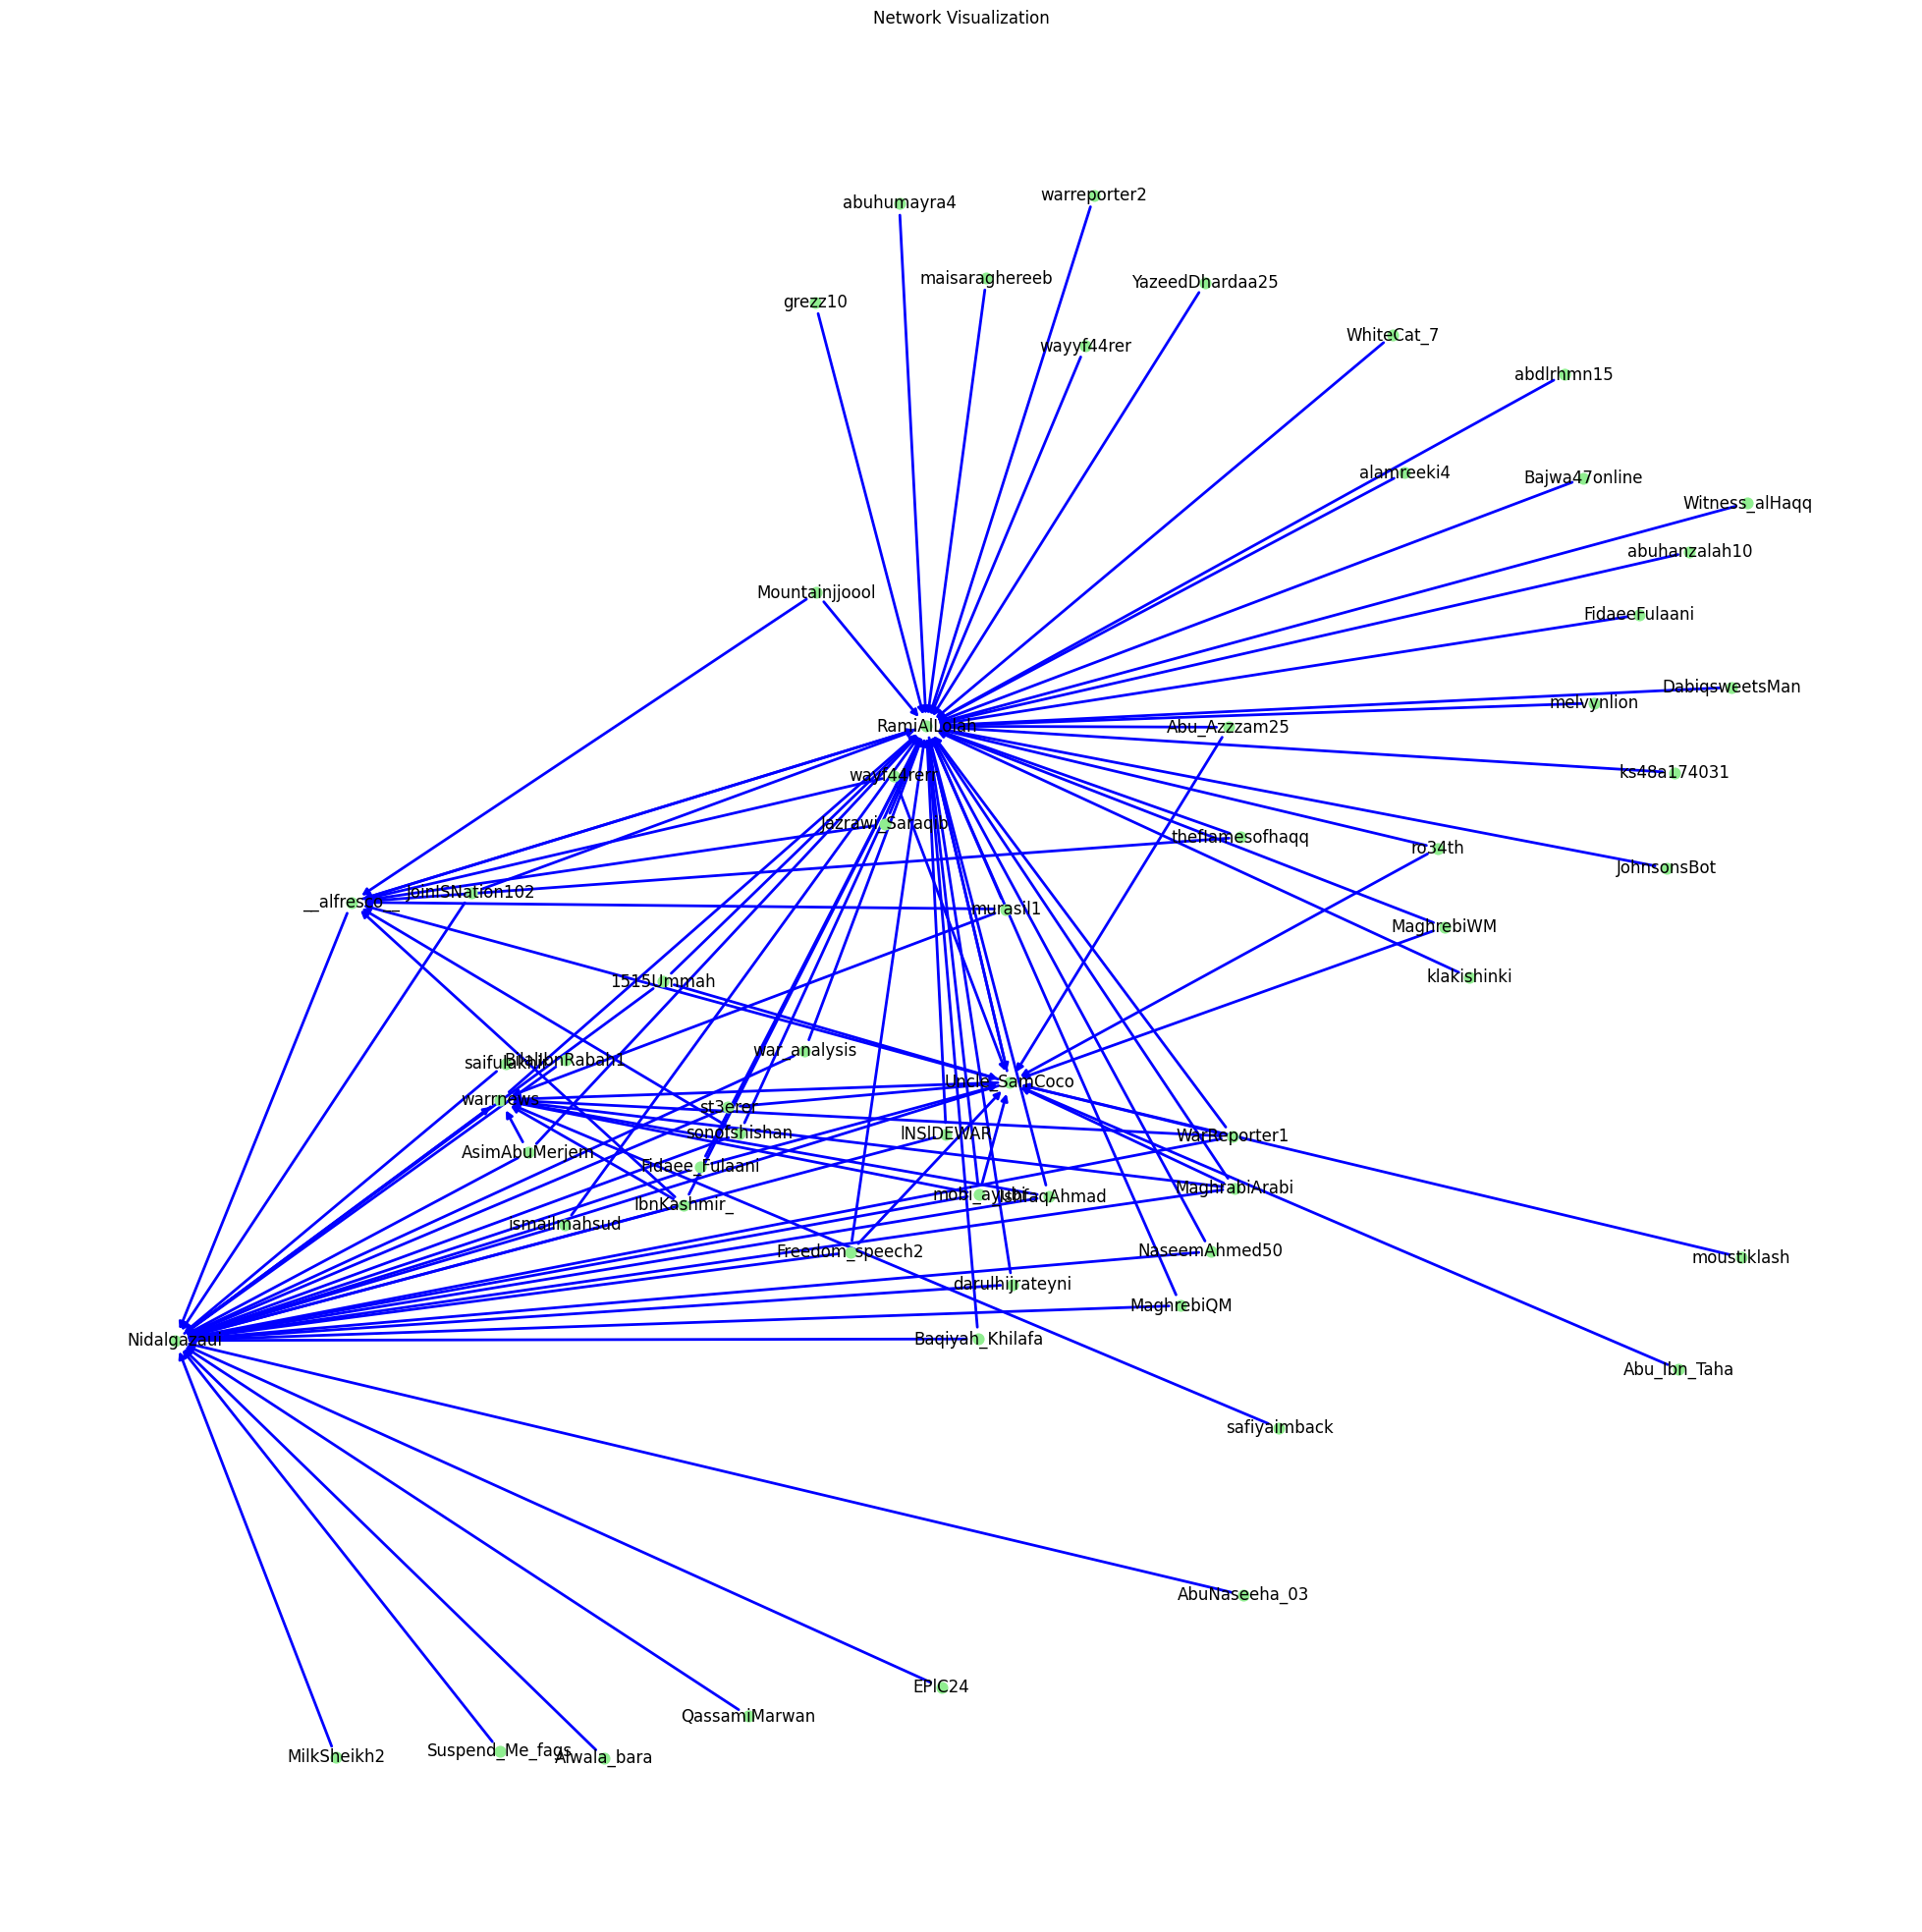

In [ ]:

pos = nx.spring_layout(t5G)
plt.figure(figsize=(25, 25))
nx.draw_networkx_nodes(t5G, pos, node_color='lightgreen', node_size=60)
nx.draw_networkx_edges(t5G, pos, edge_color='blue', width=2)
nx.draw_networkx_labels(t5G, pos, font_size=12, font_color='black')

plt.title("Network Visualization")
plt.axis('off')
plt.show()

In [ ]:
unique_usernames = mentions['username'].unique()

pr_values = np.array(list(pr.values()))
pr_values

mean = np.mean(pr_values)
median = np.median(pr_values)
std_dev = np.std(pr_values)
minimum = np.min(pr_values)
maximum = np.max(pr_values)

In [ ]:
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std_dev}")
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")

Mean: 0.013513513513513516
Median: 0.00291279596527251
Standard Deviation: 0.03231377300180646
Minimum: 0.0022167771619898166
Maximum: 0.18211635529171305


In [ ]:
pr_names = pd.DataFrame({'username': list(pr.keys()), 'pr': pr_values})
pr_names

,username,pr
0,1515Ummah,0.004538
1,Fidaee_Fulaani,0.003642
2,Nidalgazaui,0.182116
3,RamiAlLolah,0.122391
4,Uncle_SamCoco,0.073741
...,...,...
69,safiyaimback,0.002217
70,saifulakhir,0.002302
71,war_analysis,0.002217
72,abutariq041,0.002302


In [ ]:
pr_names['username'].unique().shape

(74,)

# More Cleaning

In [ ]:
nw_data = df[['username', 'tweets', 'links']]
# remove tags
#nw_data['tweets'] = nw_data['tweets'].str.replace(r'@\S+', "", regex=True)
nw_data

,username,tweets,links
0,GunsandCoffee70,'A MESSAGE TO THE TRUTHFUL IN SYRIA - SHEIKH ...,2
1,GunsandCoffee70,SHEIKH FATIH AL JAWLANI 'FOR THE PEOPLE OF IN...,2
2,GunsandCoffee70,FIRST AUDIO MEETING WITH SHEIKH FATIH AL JAWL...,2
3,GunsandCoffee70,"SHEIKH NASIR AL WUHAYSHI (HA), LEADER OF AQAP...",2
4,GunsandCoffee70,AQAP: 'RESPONSE TO SHEIKH BAGHDADIS STATEMENT...,1
...,...,...,...
17404,Uncle_SamCoco,#LT Notice that this possible strategy was men...,1
17405,nvor85j,#Breaking\n#IslamicState \n#AmaqAgency \n\n#Fr...,1
17406,nvor85j,#Breaking\n\n Iraqi forces bulldozer destroyed...,1
17407,nvor85j,#Breaking \n#AmaqAgency \n#IslamicState \n\n#E...,1


In [ ]:
pd.set_option('display.max_colwidth', None)
nw_data = nw_data.groupby('username').agg({'tweets': ','.join, 'links': 'mean'}).reset_index()
nw_data.shape

(112, 3)

In [ ]:
merged_df = pd.merge(nw_data, pr_names, on='username', how='right')
merged_df['pr'] = merged_df['pr'].fillna(0)

In [ ]:
merged_df.shape

(74, 4)

# Language Clustering
based on code from Mahdi Rafati on Medium

## Word Frequency Histogram

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

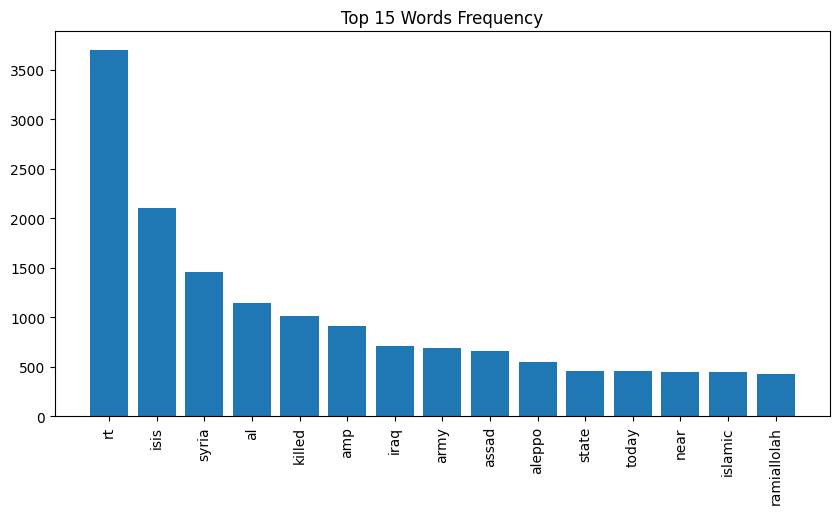

In [ ]:
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(merged_df['tweets'])

# Sum up the counts of each word in the vocabulary
word_counts = X_counts.toarray().sum(axis=0)
word_freq = [(word, word_counts[idx]) for word, idx in vectorizer.vocabulary_.items()]
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)

# Plot the top 15 most frequent words
words = [wf[0] for wf in word_freq[:15]]
counts = [wf[1] for wf in word_freq[:15]]
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 15 Words Frequency")
plt.show()

## How much did each user write?

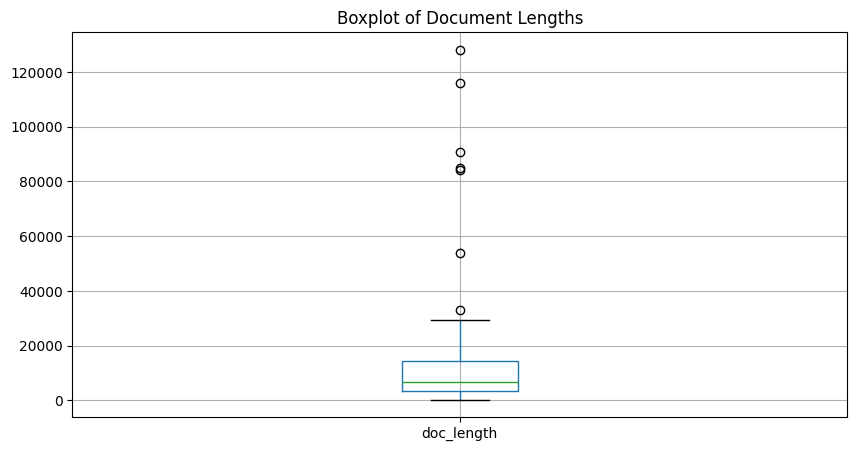

In [ ]:
# Calculate the length of each document
merged_df['doc_length'] = merged_df['tweets'].apply(len)

# Plot a boxplot of document lengths
plt.figure(figsize=(10, 5))
merged_df.boxplot(column='doc_length')
plt.title("Boxplot of Document Lengths")
plt.show()

## Preprocessing for Clustering

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import nltk

nltk.download('stopwords')

# Initialize stemmer and stopwords
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words('english'))

# Function to preprocess text
def preprocess_text(text):
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    text = ' '.join([stemmer.stem(word) for word in text.split() if word not in stop_words])
    return text

# Apply preprocessing to the text data
merged_df['clean_text'] = merged_df['tweets'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Transform the cleaned text data to TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(merged_df['clean_text'])

### K-Means Clustering

Optimizing for best cluster number

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


kmc_sil_scores = {}

for k in range(2,21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_tfidf)

    labels_kmeans = kmeans.labels_

    kmc_sil_scores[k] = silhouette_score(X_tfidf, labels_kmeans)


kmc_sil_scores

{2: 0.0339614678343606,
 3: 0.01916965562223599,
 4: 0.019755407806566955,
 5: 0.011447914478371844,
 6: 0.008196173831666712,
 7: 0.01103698609922343,
 8: 0.00900629079812091,
 9: 0.008403855692881218,
 10: 0.007906415236500697,
 11: -0.015304262207866244,
 12: -0.014259399135239407,
 13: -0.012886167898339084,
 14: -0.011393724944176436,
 15: -0.01279915781255704,
 16: -0.01226264855811941,
 17: -0.00977327745832253,
 18: -0.008580327884279565,
 19: -0.008764963081633917,
 20: -0.0070869793419876944}

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_tfidf)

labels_louvain = kmeans.labels_

silhouette_score(X_tfidf, labels_kmeans)
labels_kmeans

array([ 1,  1, 11,  8,  2,  7,  7, 10, 14, 10, 11,  1, 17, 10,  2, 10,  4,
       18,  8, 11,  9, 10,  4, 10,  1, 15,  4,  0,  8, 10,  2,  3, 10,  1,
       10,  6,  8,  1, 16,  5,  8,  8, 10, 10,  1, 10, 10,  8, 10, 12,  1,
       10,  1,  3, 10, 10,  7,  1,  9, 10,  7, 19, 16,  1,  1, 10, 10,  6,
       10, 11, 13,  1,  9,  1], dtype=int32)

On the silhouette score: https://medium.com/@Suraj_Yadav/silhouette-coefficient-explained-with-a-practical-example-assessing-cluster-fit-c0bb3fdef719#:~:text=Step%201:%20Calculate%20Cohesion%20for,the%20distinctness%20of%20the%20clusters.

In [ ]:
max_score = max(kmc_sil_scores.values())
max_score

0.0339614678343606

### DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5, metric='cosine')
dbscan.fit(X_tfidf)

labels_dbscan = dbscan.labels_
silhouette_score(X_tfidf, labels_dbscan)


0.00331012202539093

## Network Clustering

Global Clustering Coefficient

In [ ]:
nx.average_clustering(G)

0.2237506323851562

In [ ]:
clustering_values = list(nx.clustering(G).values())

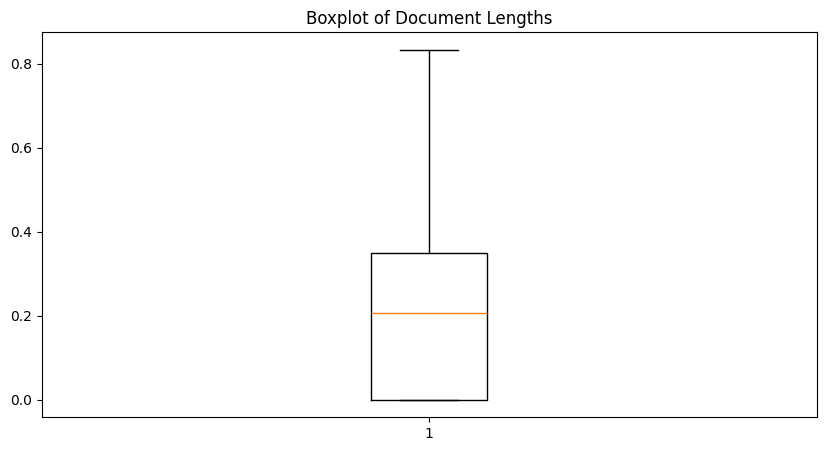

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(clustering_values)
plt.title("Boxplot of Document Lengths")
plt.show()

In [ ]:
in_ds = network['username'].unique()
network

,username,mentions,weight
0,1515Ummah,Fidaee_Fulaani,1
1,1515Ummah,Nidalgazaui,1
2,1515Ummah,RamiAlLolah,1
3,1515Ummah,Uncle_SamCoco,2
4,432Mryam,abuayisha102,1
...,...,...,...
239,wayf44rerr,Jazrawi_Saraqib,1
240,wayf44rerr,Uncle_SamCoco,2
241,wayf44rerr,__alfresco__,1
242,wayf44rerr,st3erer,3


In [ ]:
communities = nx.community.louvain_communities(G, seed=123)

In [ ]:
len(G.nodes())

74

In [ ]:
#!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS
#!pip install --upgrade pip

#!pip install --upgrade Pillow
import string
#!pip install --upgrade matplotlib



In [ ]:
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


## Average Community Statistics

Community 1

In [ ]:
communities[0]

{'432Mryam', 'abuayisha102'}

In [ ]:
com1 = merged_df[merged_df['username'].isin(communities[0])][['username','tweets']]

In [ ]:
loc = df[df['username'].isin(communities[0])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,Nowhere,1


Community 2

In [ ]:
communities[1]

{'AbuNaseeha_03',
 'Alwala_bara',
 'Baqiyah_Khilafa',
 'Fidaee_Fulaani',
 'Jazrawi_Joulan',
 'MaghrabiArabi',
 'MaghrebiQM',
 'ManKhalfahum',
 'QassamiMarwan',
 'abuhumayra4',
 'ansarakhilafa',
 'grezz10',
 'ismailmahsud'}

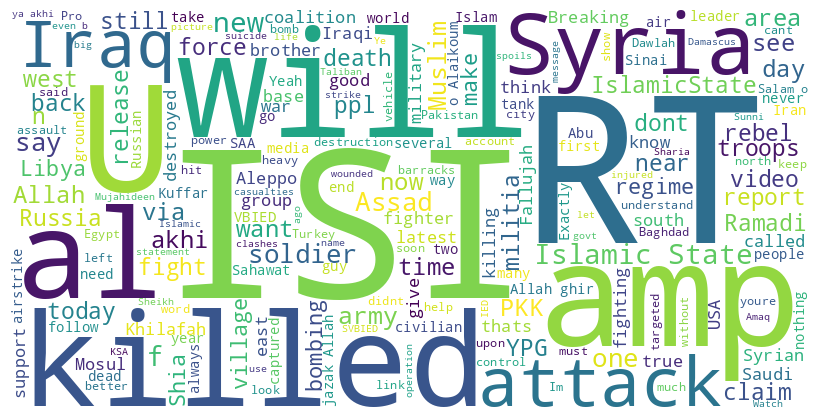

In [ ]:
com2 = merged_df[merged_df['username'].isin(communities[1])][['username','tweets']]
tweets_com2 = str(com2['tweets'])
tweets_com2 = tweets_com2.replace("\\n", "")
tweets_com2 = tweets_com2.replace(f"[{string.punctuation}]", "")
tweets_com2 = tweets_com2.replace("\\", "")
tweets_com2 = tweets_com2.replace("'", "")
tweets_com2 = tweets_com2.replace(".", "")
tweets_com2 = tweets_com2.replace(",", "")
tweets_com2 = re.sub(r'@\w+', '', tweets_com2)

comment_words = ''
stopwords = set(STOPWORDS)


wordcloud = WordCloud(stopwords=stopwords, width=800, height=400, background_color='white').generate(tweets_com2)


# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
network2 = network[network['username'].isin(communities[1])]
network2 = network2[network2['mentions'].isin(communities[1])]
network2

,username,mentions,weight
6,AbuNaseeha_03,MaghrebiQM,7
14,Alwala_bara,QassamiMarwan,1
22,Baqiyah_Khilafa,Jazrawi_Joulan,2
37,Fidaee_Fulaani,MaghrebiQM,8
64,MaghrabiArabi,Jazrawi_Joulan,9
66,MaghrabiArabi,MaghrebiQM,2
68,MaghrabiArabi,ManKhalfahum,1
70,MaghrabiArabi,QassamiMarwan,4
73,MaghrabiArabi,ansarakhilafa,1
74,MaghrabiArabi,ismailmahsud,7


In [ ]:
G2 = nx.DiGraph()

for column, row in network2.iterrows():
    G2.add_edge(row['username'], row['mentions'])

pr2 = nx.pagerank(G2, alpha=0.85)
pr2

{'AbuNaseeha_03': 0.051508610016494295,
 'MaghrebiQM': 0.19135170768961596,
 'Alwala_bara': 0.04013666864031891,
 'QassamiMarwan': 0.10475386431462869,
 'Baqiyah_Khilafa': 0.04013666864031891,
 'Jazrawi_Joulan': 0.0933819229384533,
 'Fidaee_Fulaani': 0.051508610016494295,
 'MaghrabiArabi': 0.13503448990473044,
 'ManKhalfahum': 0.0933819229384533,
 'ansarakhilafa': 0.05926609880992712,
 'ismailmahsud': 0.05926609880992712,
 'abuhumayra4': 0.04013666864031891,
 'grezz10': 0.04013666864031891}

In [ ]:
G2.out_degree()

OutDegreeView({'AbuNaseeha_03': 1, 'MaghrebiQM': 0, 'Alwala_bara': 1, 'QassamiMarwan': 2, 'Baqiyah_Khilafa': 1, 'Jazrawi_Joulan': 0, 'Fidaee_Fulaani': 1, 'MaghrabiArabi': 6, 'ManKhalfahum': 0, 'ansarakhilafa': 1, 'ismailmahsud': 0, 'abuhumayra4': 3, 'grezz10': 1})

In [ ]:
network2[network2['username'] == "MaghrabiArabi"]

,username,mentions,weight
64,MaghrabiArabi,Jazrawi_Joulan,9
66,MaghrabiArabi,MaghrebiQM,2
68,MaghrabiArabi,ManKhalfahum,1
70,MaghrabiArabi,QassamiMarwan,4
73,MaghrabiArabi,ansarakhilafa,1
74,MaghrabiArabi,ismailmahsud,7


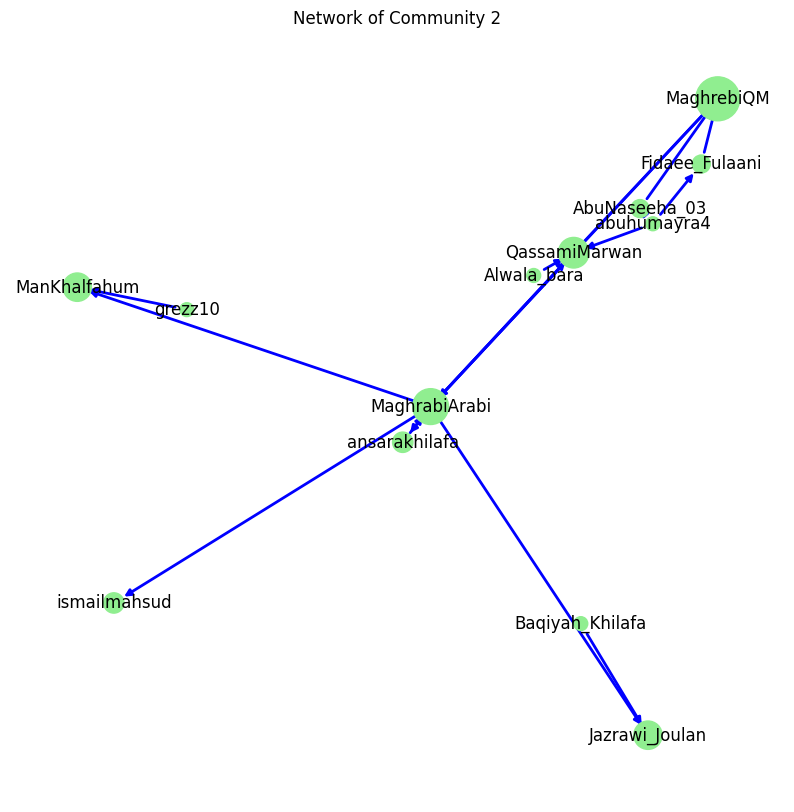

In [ ]:
max_pr2 = max(pr2.values())
min_pr2 = min(pr2.values())

node_colors = [100 + (pr2[node] - min_pr2) / (max_pr2 - min_pr2) * 900 for node in G2.nodes]


pos = nx.spring_layout(G2)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G2, pos, node_color="lightgreen", node_size=node_colors)
nx.draw_networkx_edges(G2, pos, edge_color='blue', width=2)
nx.draw_networkx_labels(G2, pos, font_size=12, font_color='black')

plt.title("Network of Community 2")
plt.axis('off')
plt.show()

In [ ]:
loc = df[df['username'].isin(communities[1])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,"28th Street, Qamar Precint",1
1,Among The Muslims,1
2,"Amsterdam, The Netherlands",1
3,"Antas, Bahia",1
4,Dunya,1
5,S.Wazirstan|Mahsud not a Wazir,1
6,Wilayah Twitter,1
7,أسير الدنيا,1


In [ ]:
wcl2 = merged_df[merged_df['username'].isin(communities[1])]
wcl2 = wcl2[["username", "links", "doc_length"]]
avg = np.vstack([wcl2, ["Averages", np.trunc(wcl2["links"].mean()*1000)/1000, np.trunc(wcl2["doc_length"].mean())]])
wcl2 = pd.DataFrame(avg, columns= wcl2.columns)
wcl2

,username,links,doc_length
0,Fidaee_Fulaani,0.563025,22910
1,AbuNaseeha_03,0.666667,5177
2,MaghrebiQM,0.453846,13570
3,Alwala_bara,0.909091,4357
4,QassamiMarwan,0.415584,6972
5,Baqiyah_Khilafa,0.405797,5389
6,Jazrawi_Joulan,0.566667,4779
7,MaghrabiArabi,0.319403,23572
8,ManKhalfahum,0.55,1951
9,ansarakhilafa,0.947368,1637


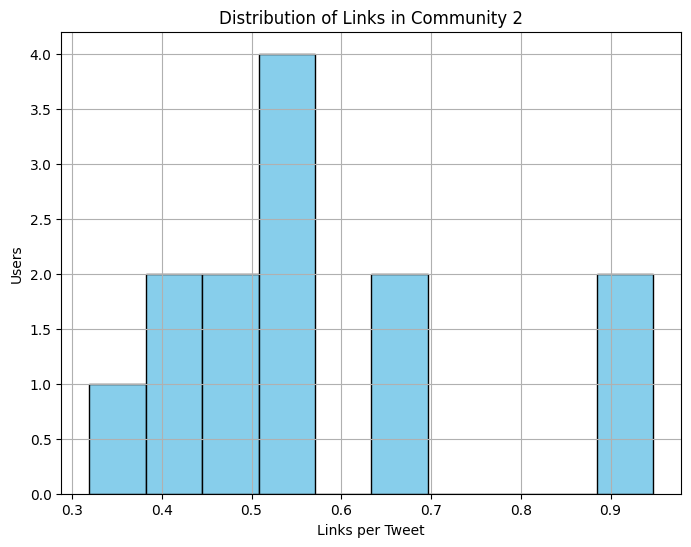

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl2['links'][:13]), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Links in Community 2')
plt.xlabel('Links per Tweet')
plt.ylabel('Users')
plt.grid(True)
plt.show()

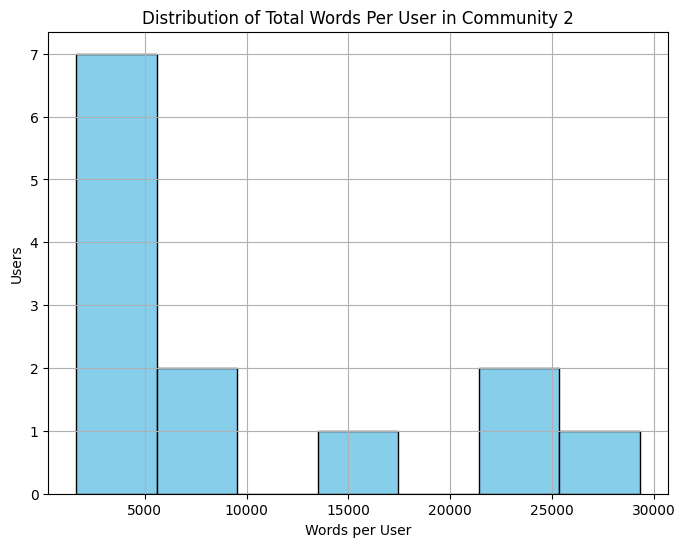

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl2['doc_length'][:13]), bins=7, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Words Per User in Community 2')
plt.xlabel('Words per User')
plt.ylabel('Users')
plt.grid(True)
plt.show()

In [ ]:
sum(dict(G2.degree()).values())/12

2.8333333333333335

In [ ]:
np.std(np.array(list(dict(G2.degree()).values())))

1.942973990817706

In [ ]:
np.std(list(pr2.values()))

0.04395406269384667

Community 3

In [ ]:
communities[2]

{'AsimAbuMerjem',
 'FidaeeFulaani',
 'MilkSheikh2',
 '_IshfaqAhmad',
 'ks48a174031',
 'moustiklash'}

In [ ]:
com3 = merged_df[merged_df['username'].isin(communities[2])]
tweets_com3 = str(com3['tweets'])
tweets_com3 = tweets_com3.replace("\\n", "")
tweets_com3 = tweets_com3.replace(f"[{string.punctuation}]", "")
tweets_com3 = tweets_com3.replace("\\", "")
tweets_com3 = tweets_com3.replace("'", "")
tweets_com3 = tweets_com3.replace(".", "")
tweets_com3 = tweets_com3.replace(",", "")
tweets_com3 = re.sub(r'@\w+', '', tweets_com3)

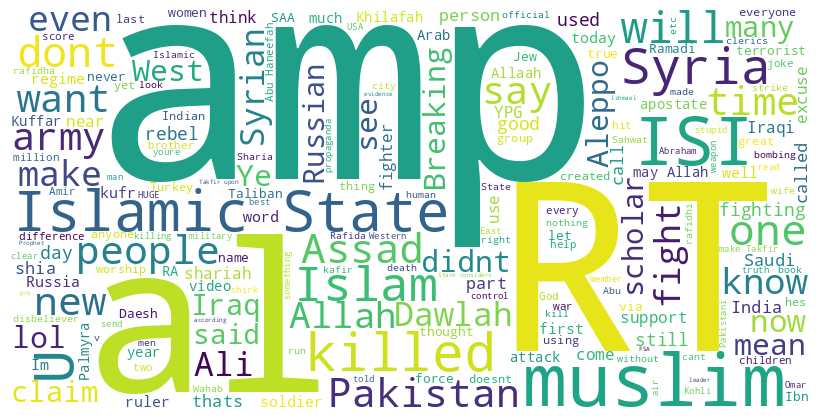

In [ ]:
comment_words = ''
stopwords = set(STOPWORDS)


wordcloud = WordCloud(stopwords=stopwords, width=800, height=400, background_color='white').generate(tweets_com3)


# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
network3 = network[network['username'].isin(communities[2])]
network3 = network3[network3['mentions'].isin(communities[2])]
network3

,username,mentions,weight
16,AsimAbuMerjem,MilkSheikh2,23
34,FidaeeFulaani,MilkSheikh2,3
36,FidaeeFulaani,moustiklash,6
82,MilkSheikh2,AsimAbuMerjem,5
133,_IshfaqAhmad,MilkSheikh2,1
174,ks48a174031,FidaeeFulaani,1
197,moustiklash,FidaeeFulaani,1
198,moustiklash,MilkSheikh2,1
201,moustiklash,_IshfaqAhmad,15


In [ ]:
G3 = nx.DiGraph()

for column, row in network3.iterrows():
    G3.add_edge(row['username'], row['mentions'])

pr3 = nx.pagerank(G3, alpha=0.85)
pr3

{'AsimAbuMerjem': 0.3922062533600251,
 'MilkSheikh2': 0.4320044287811405,
 'FidaeeFulaani': 0.060634770251065846,
 'moustiklash': 0.05076977735670299,
 '_IshfaqAhmad': 0.03938477025106585,
 'ks48a174031': 0.025}

In [ ]:
G3.in_degree()

InDegreeView({'AsimAbuMerjem': 1, 'MilkSheikh2': 4, 'FidaeeFulaani': 2, 'moustiklash': 1, '_IshfaqAhmad': 1, 'ks48a174031': 0})

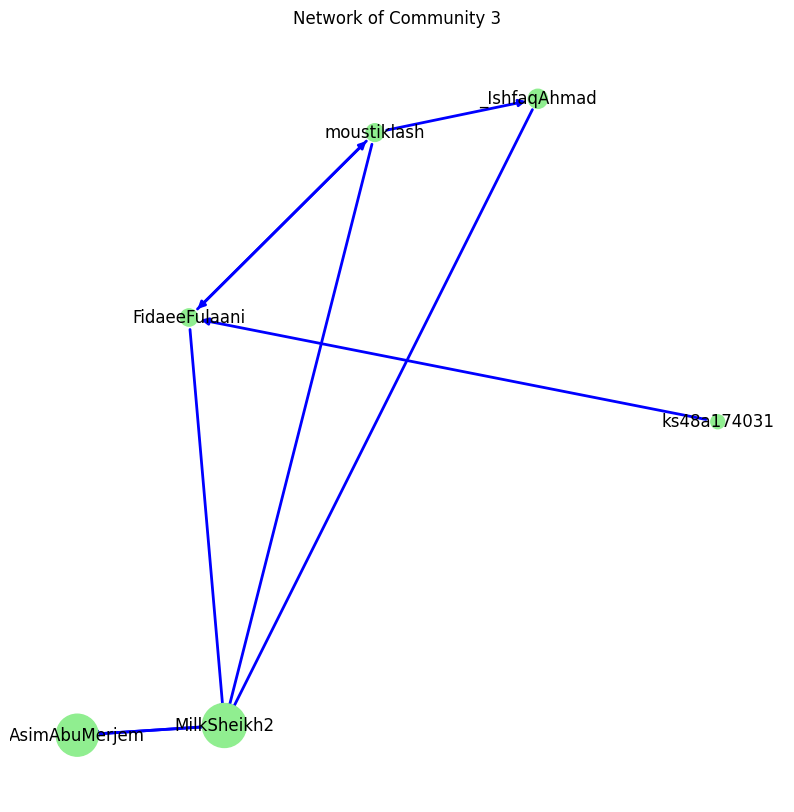

In [ ]:
max_pr3 = max(pr3.values())
min_pr3 = min(pr3.values())

node_size = [100 + (pr3[node] - min_pr3) / (max_pr3 - min_pr3) * 900 for node in G3.nodes]

pos = nx.spring_layout(G3)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G3, pos, node_color='lightgreen', node_size=node_size)
nx.draw_networkx_edges(G3, pos, edge_color='blue', width=2)
nx.draw_networkx_labels(G3, pos, font_size=12, font_color='black')

plt.title("Network of Community 3")
plt.axis('off')
plt.show()

In [ ]:
loc = df[df['username'].isin(communities[2])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,"28th Street, Qamar Precint",1
1,اُمتِ مُسلمہ ولایت کشمیر,1


In [ ]:
wcl3 = merged_df[merged_df['username'].isin(communities[2])]
wcl3 = wcl3[["username", "links", "doc_length"]]
avg = np.vstack([wcl3, ["Averages", np.trunc(wcl3["links"].mean()*1000)/1000, np.trunc(wcl3["doc_length"].mean())]])
wcl3 = pd.DataFrame(avg, columns= wcl3.columns)
wcl3

,username,links,doc_length
0,AsimAbuMerjem,0.428571,23385
1,MilkSheikh2,0.234568,14187
2,FidaeeFulaani,0.706422,10112
3,moustiklash,0.736264,8403
4,_IshfaqAhmad,0.159204,53803
5,ks48a174031,0.8,534
6,Averages,0.51,18404.0


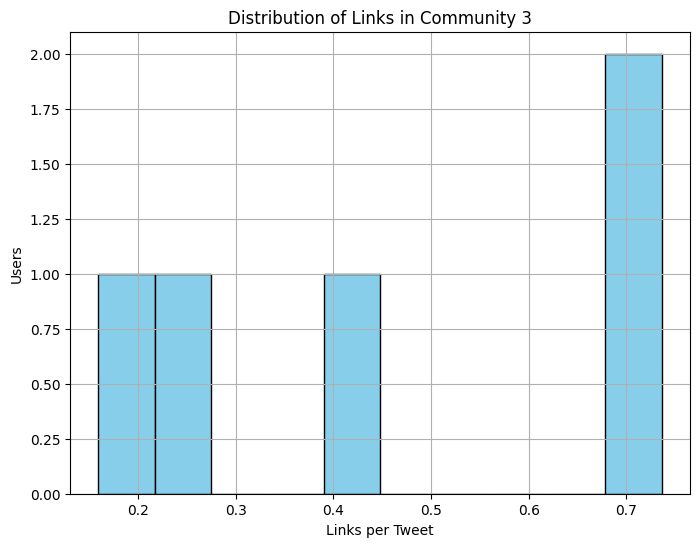

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl3['links'][:5]), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Links in Community 3')
plt.xlabel('Links per Tweet')
plt.ylabel('Users')
plt.grid(True)
plt.show()

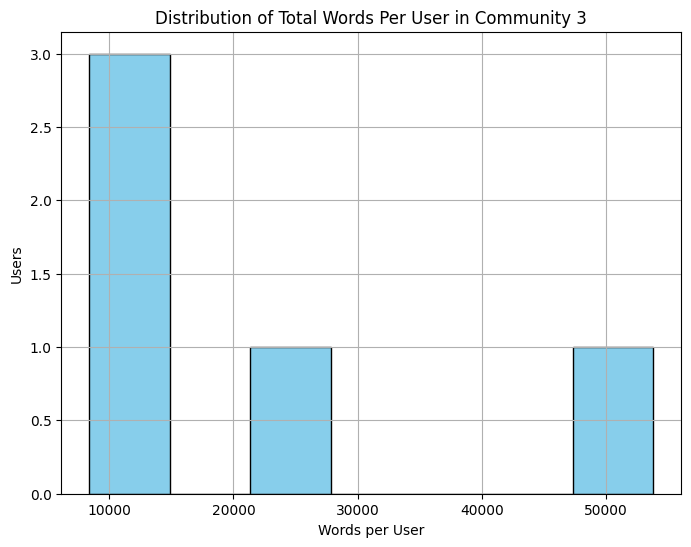

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl3['doc_length'][:5]), bins=7, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Words Per User in Community 3')
plt.xlabel('Words per User')
plt.ylabel('Users')
plt.grid(True)
plt.show()

In [ ]:
sum(dict(G3.degree()).values())/5

3.6

In [ ]:
np.std(list(pr3.values()))

0.17426857183599254

Community 4

In [ ]:
communities[3]

{'AbuMusab_110',
 'BilalIbnRabah1',
 'DawlaWitness11',
 'EPlC24',
 'IbnKashmir_',
 'Jazrawi_Saraqib',
 'JohnsonsBot',
 'MaghrebiWM',
 'Mountainjjoool',
 'WarReporter1',
 'Witness_alHaqq',
 '__alfresco__',
 'abuayisha108',
 'abutariq040',
 'kIakishini5',
 'klakishinki',
 'melvynlion',
 'murasil1',
 'sonofshishan',
 'st3erer',
 'thefIamesofhaqq',
 'wayf44rerr'}

In [ ]:
com4 = merged_df[merged_df['username'].isin(communities[3])][['username','tweets']]
tweets_com4 = str(com4['tweets'])
tweets_com4 = tweets_com4.replace("\\n", "")
tweets_com4 = tweets_com4.replace(f"[{string.punctuation}]", "")
tweets_com4 = tweets_com4.replace("\\", "")
tweets_com4 = tweets_com4.replace("'", "")
tweets_com4 = tweets_com4.replace(".", "")
tweets_com4 = tweets_com4.replace(",", "")
tweets_com4 = re.sub(r'@\w+', '', tweets_com4)

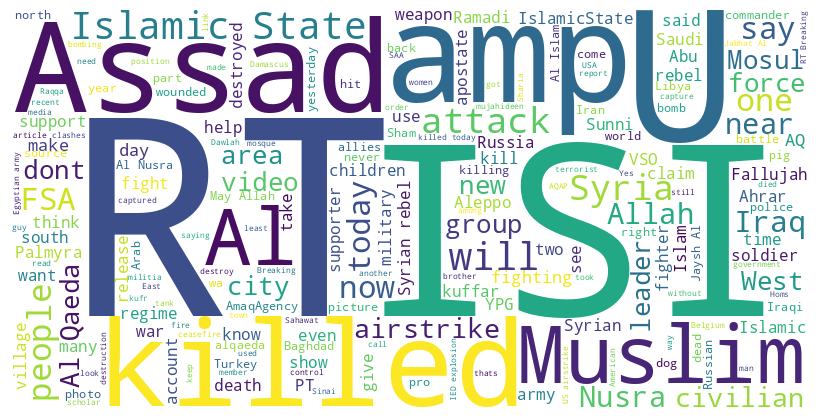

In [ ]:
comment_words = ''
stopwords = set(STOPWORDS)


wordcloud = WordCloud(stopwords=stopwords, width=800, height=400, background_color='white').generate(tweets_com4)


# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
loc = df[df['username'].isin(communities[3])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,AP,1
1,Among mushrikeen,1
2,"Bandar Seri Begawan, Negara Brunei Darussalam",1
3,"Lake City, GA",1
4,Land of Allah,1
5,Middle of Nowhere,1
6,Nowhere,1
7,Wilayah Kashmir,1
8,Worldwide contributions,1


In [ ]:
network4 = network[network['username'].isin(communities[3])]
network4 = network4[network4['mentions'].isin(communities[3])]
network4

,username,mentions,weight
5,AbuMusab_110,kIakishini5,3
26,BilalIbnRabah1,WarReporter1,1
28,DawlaWitness11,MaghrebiWM,1
32,EPlC24,WarReporter1,2
45,IbnKashmir_,EPlC24,2
47,IbnKashmir_,Jazrawi_Saraqib,1
51,IbnKashmir_,WarReporter1,3
52,IbnKashmir_,__alfresco__,3
54,Jazrawi_Saraqib,MaghrebiWM,7
56,Jazrawi_Saraqib,__alfresco__,1


In [ ]:
G4 = nx.DiGraph()

for column, row in network4.iterrows():
    G4.add_edge(row['username'], row['mentions'], weight=row['weight'])

pr4 = nx.pagerank(G4, alpha=0.85)
pr4

{'AbuMusab_110': 0.08496730644821465,
 'kIakishini5': 0.08247486510083774,
 'BilalIbnRabah1': 0.010254069309933856,
 'WarReporter1': 0.18250618140741925,
 'DawlaWitness11': 0.011343583246918169,
 'MaghrebiWM': 0.07406109619585953,
 'EPlC24': 0.022611590103969986,
 'IbnKashmir_': 0.010254069309933856,
 'Jazrawi_Saraqib': 0.10013322906559127,
 '__alfresco__': 0.04412181046335481,
 'wayf44rerr': 0.07549461353026421,
 'Mountainjjoool': 0.010254069309933856,
 'klakishinki': 0.04903641650922533,
 'thefIamesofhaqq': 0.04903641650922533,
 'Witness_alHaqq': 0.010254069309933856,
 'JohnsonsBot': 0.014868481278338008,
 'murasil1': 0.014799960358378956,
 'st3erer': 0.111266736517807,
 'abuayisha108': 0.010254069309933856,
 'abutariq040': 0.010254069309933856,
 'melvynlion': 0.010254069309933856,
 'sonofshishan': 0.011499228095058784}

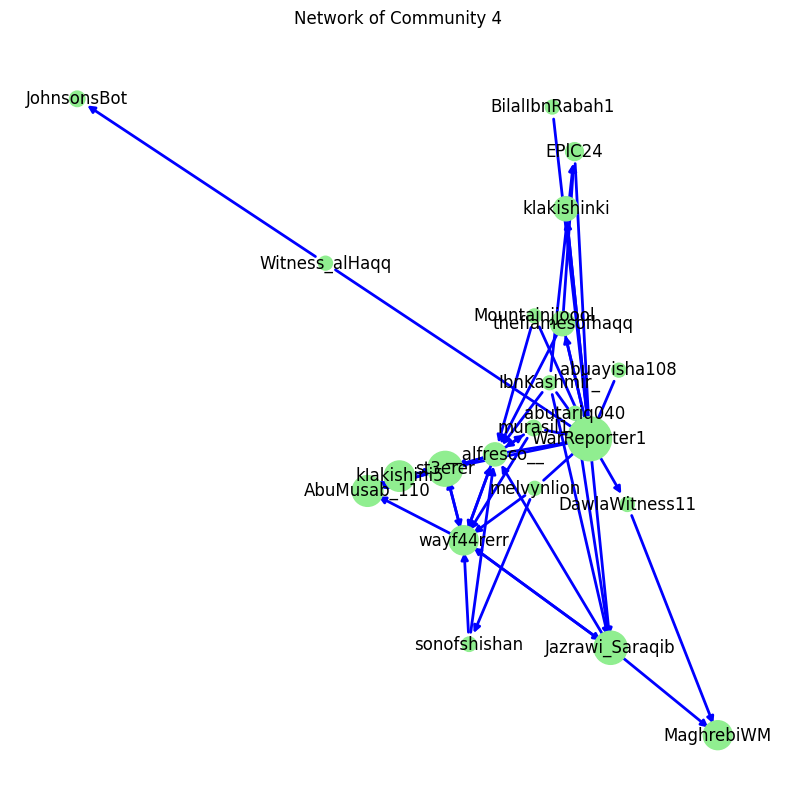

In [ ]:
max_pr4 = max(pr4.values())
min_pr4 = min(pr4.values())

node_size = [100 + (pr4[node] - min_pr4) / (max_pr4 - min_pr4) * 900 for node in G4.nodes]

pos = nx.spring_layout(G4)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G4, pos, node_color='lightgreen', node_size=node_size)
nx.draw_networkx_edges(G4, pos, edge_color='blue', width=2)
nx.draw_networkx_labels(G4, pos, font_size=12, font_color='black')

plt.title("Network of Community 4")
plt.axis('off')
plt.show()

In [ ]:
G4.in_degree()

InDegreeView({'AbuMusab_110': 3, 'kIakishini5': 1, 'BilalIbnRabah1': 0, 'WarReporter1': 13, 'DawlaWitness11': 1, 'MaghrebiWM': 2, 'EPlC24': 2, 'IbnKashmir_': 0, 'Jazrawi_Saraqib': 4, '__alfresco__': 7, 'wayf44rerr': 6, 'Mountainjjoool': 0, 'klakishinki': 1, 'thefIamesofhaqq': 1, 'Witness_alHaqq': 0, 'JohnsonsBot': 1, 'murasil1': 1, 'st3erer': 3, 'abuayisha108': 0, 'abutariq040': 0, 'melvynlion': 0, 'sonofshishan': 1})

In [ ]:
loc = df[df['username'].isin(communities[3])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,AP,1
1,Among mushrikeen,1
2,"Bandar Seri Begawan, Negara Brunei Darussalam",1
3,"Lake City, GA",1
4,Land of Allah,1
5,Middle of Nowhere,1
6,Nowhere,1
7,Wilayah Kashmir,1
8,Worldwide contributions,1


In [ ]:
wcl4 = merged_df[merged_df['username'].isin(communities[3])]
wcl4 = wcl4[["username", "links", "doc_length"]]
avg = np.vstack([wcl4, ["Averages", np.trunc(wcl4["links"].mean()*1000)/1000, np.trunc(wcl4["doc_length"].mean())]])
wcl4 = pd.DataFrame(avg, columns= wcl4.columns)
wcl4

,username,links,doc_length
0,AbuMusab_110,0.545455,5525
1,kIakishini5,0.88,2274
2,Jazrawi_Saraqib,0.549451,8015
3,WarReporter1,0.710977,115968
4,BilalIbnRabah1,0.605263,3224
5,DawlaWitness11,0.596774,5159
6,MaghrebiWM,0.586207,8950
7,EPlC24,0.760563,5648
8,IbnKashmir_,0.708333,15313
9,__alfresco__,0.57438,19665


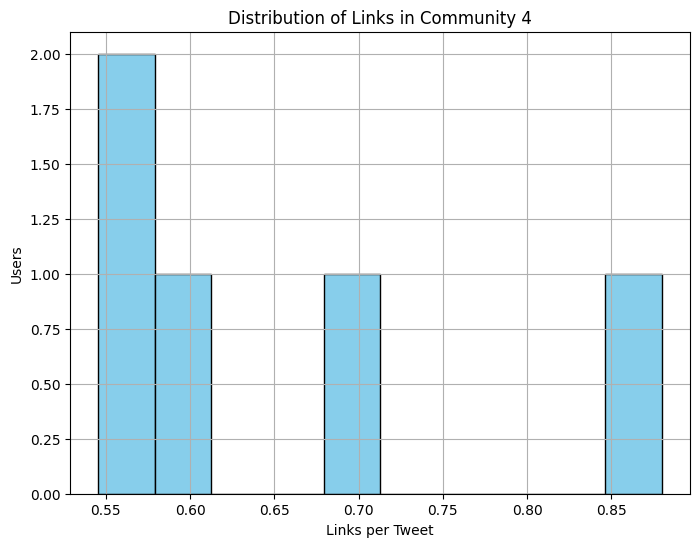

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl4['links'][:5]), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Links in Community 4')
plt.xlabel('Links per Tweet')
plt.ylabel('Users')
plt.grid(True)
plt.show()

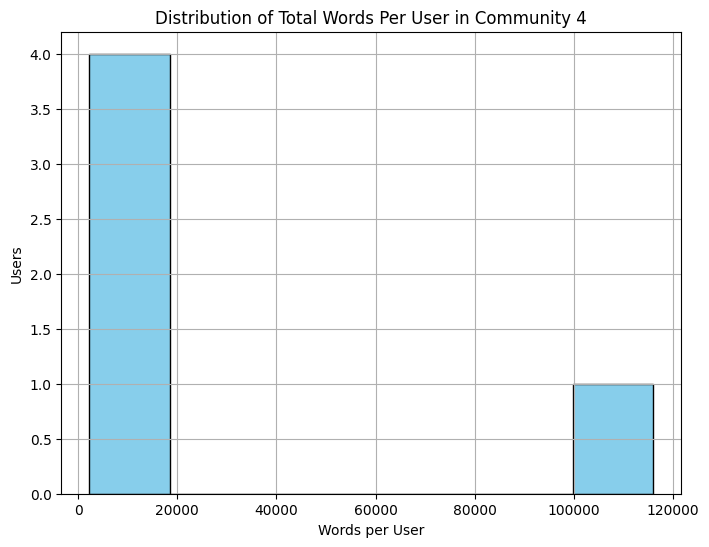

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl4['doc_length'][:5]), bins=7, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Words Per User in Community 4')
plt.xlabel('Words per User')
plt.ylabel('Users')
plt.grid(True)
plt.show()

Community 5

In [ ]:
communities[4]

{'Nidalgazaui',
 'Suspend_Me_fags',
 'abutariq041',
 'safiyaimback',
 'saifulakhir',
 'war_analysis',
 'warrnews'}

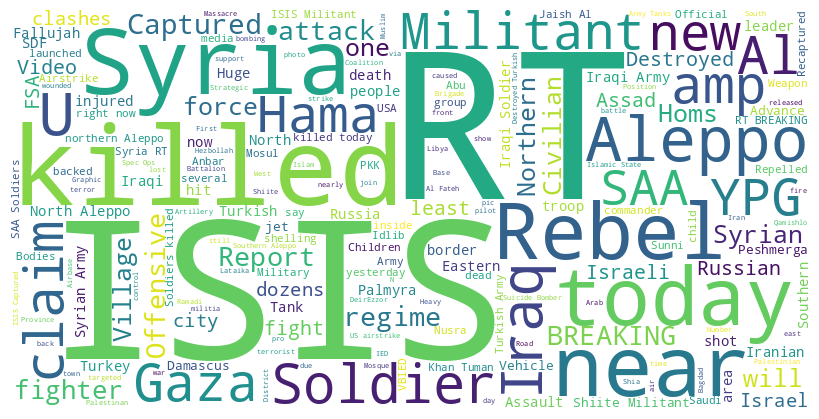

In [ ]:
com5 = merged_df[merged_df['username'].isin(communities[4])][['username','tweets']]
tweets_com5 = str(com5['tweets'])
tweets_com5 = tweets_com5.replace("\\n", "")
tweets_com5 = tweets_com5.replace(f"[{string.punctuation}]", "")
tweets_com5 = tweets_com5.replace("\\", "")
tweets_com5 = tweets_com5.replace("'", "")
tweets_com5 = tweets_com5.replace(".", "")
tweets_com5 = tweets_com5.replace(",", "")
tweets_com5 = re.sub(r'@\w+', '', tweets_com5)

comment_words = ''
stopwords = set(STOPWORDS)


wordcloud = WordCloud(stopwords=stopwords, width=800, height=400, background_color='white').generate(tweets_com5)


# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
loc = df[df['username'].isin(communities[4])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,Germany,1
1,Ghurabā,1
2,I hate snitches,1
3,"Singaparna, Indonesia",1
4,darl mushrequeen,1
5,world,1


In [ ]:
loc[loc["location"] == "Ghurabā"]

,username,location
10721,safiyaimback,Ghurabā
10752,safiyaimback,Ghurabā
10760,safiyaimback,Ghurabā
10761,safiyaimback,Ghurabā
10764,safiyaimback,Ghurabā
...,...,...
14734,safiyaimback,Ghurabā
14735,safiyaimback,Ghurabā
14775,safiyaimback,Ghurabā
14778,safiyaimback,Ghurabā


In [ ]:
network5 = network[network['username'].isin(communities[4])]
network5 = network5[network5['mentions'].isin(communities[4])]
network5

,username,mentions,weight
93,Nidalgazaui,warrnews,3
99,Suspend_Me_fags,Nidalgazaui,1
211,safiyaimback,Suspend_Me_fags,1
212,safiyaimback,warrnews,2
213,saifulakhir,Nidalgazaui,1
228,war_analysis,Nidalgazaui,9
230,war_analysis,abutariq041,1
231,war_analysis,saifulakhir,1
235,warrnews,Nidalgazaui,166


In [ ]:
G5 = nx.DiGraph()

for column, row in network5.iterrows():
    G5.add_edge(row['username'], row['mentions'], weight=row['weight'])

pr5 = nx.pagerank(G5, alpha=0.85)
pr5

{'Nidalgazaui': 0.4471946983662979,
 'warrnews': 0.41874232303745934,
 'Suspend_Me_fags': 0.031638713533300965,
 'safiyaimback': 0.02465354301296179,
 'saifulakhir': 0.02655858951850884,
 'war_analysis': 0.02465354301296179,
 'abutariq041': 0.02655858951850884}

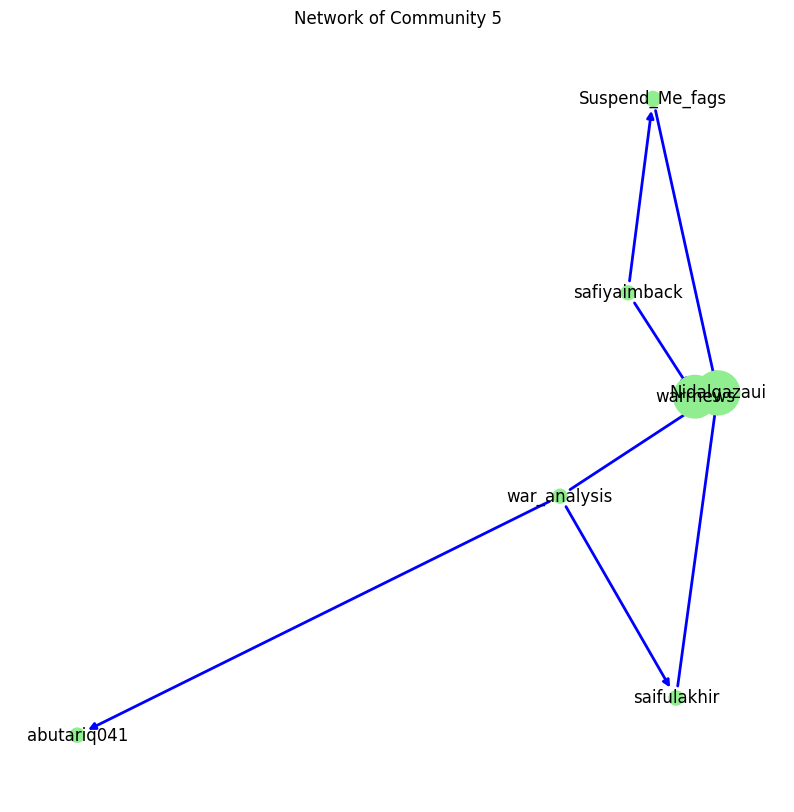

In [ ]:
max_pr5 = max(pr5.values())
min_pr5 = min(pr5.values())

node_size = [100 + (pr5[node] - min_pr5) / (max_pr5 - min_pr5) * 900 for node in G5.nodes]

pos = nx.spring_layout(G5)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G5, pos, node_color='lightgreen', node_size=node_size)
nx.draw_networkx_edges(G5, pos, edge_color='blue', width=2)
nx.draw_networkx_labels(G5, pos, font_size=12, font_color='black')

plt.title("Network of Community 5")
plt.axis('off')
plt.show()

In [ ]:
wcl5 = merged_df[merged_df['username'].isin(communities[4])]
wcl5 = wcl5[["username", "links", "doc_length"]]
avg = np.vstack([wcl5, ["Averages", np.trunc(wcl5["links"].mean()*1000)/1000, np.trunc(wcl5["doc_length"].mean())]])
wcl5 = pd.DataFrame(avg, columns= wcl5.columns)
wcl5

,username,links,doc_length
0,Nidalgazaui,0.497297,33162
1,warrnews,0.768868,90742
2,Suspend_Me_fags,0.5,1726
3,safiyaimback,0.488095,6804
4,saifulakhir,0.6,4073
5,war_analysis,0.614286,6771
6,abutariq041,0.459459,2544
7,Averages,0.561,20831.0


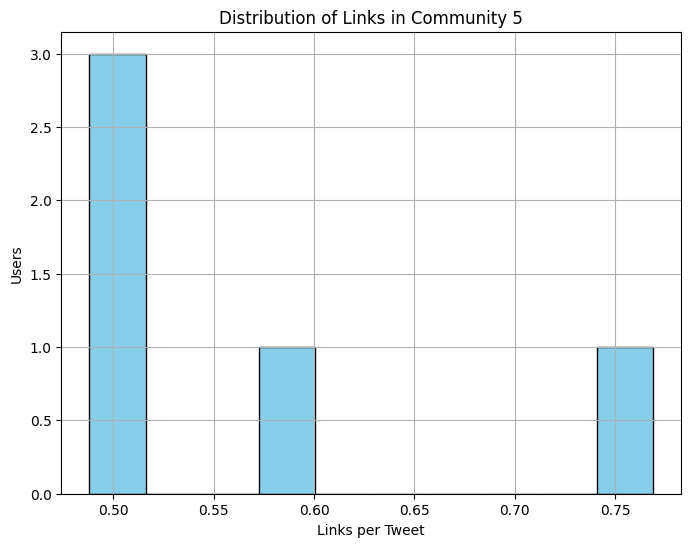

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl5['links'][:5]), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Links in Community 5')
plt.xlabel('Links per Tweet')
plt.ylabel('Users')
plt.grid(True)
plt.show()

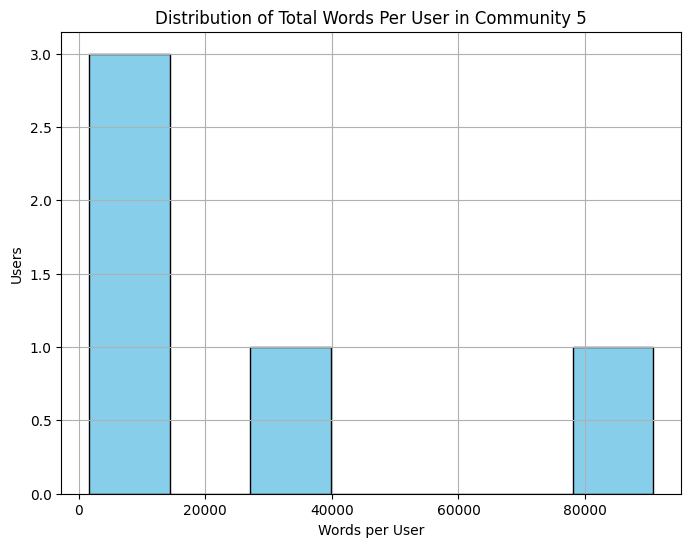

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl5['doc_length'][:5]), bins=7, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Words Per User in Community 5')
plt.xlabel('Words per User')
plt.ylabel('Users')
plt.grid(True)
plt.show()

Communities 6

In [ ]:
communities[5]

{'1515Ummah',
 'Abu_Azzzam25',
 'Abu_Ibn_Taha',
 'Bajwa47online',
 'DabiqsweetsMan',
 'Freedom_speech2',
 'JoinISNation102',
 'NaseemAhmed50',
 'RamiAlLolah',
 'Uncle_SamCoco',
 'WhiteCat_7',
 'YazeedDhardaa25',
 'abdlrhmn15',
 'abuhanzalah10',
 'alamreeki4',
 'darulhijrateyni',
 'lNSlDEWAR',
 'maisaraghereeb',
 'mobi_ayubi',
 'ro34th',
 'warreporter2',
 'wayyf44rer'}

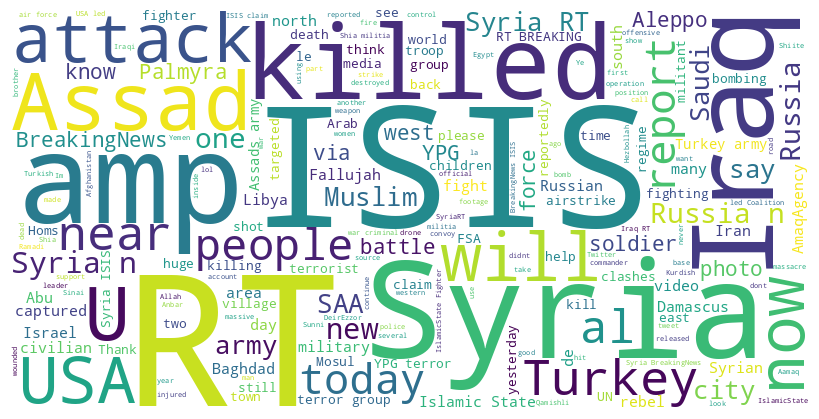

In [ ]:
com6 = merged_df[merged_df['username'].isin(communities[5])]
tweets_com6 = str(com6['tweets'])
tweets_com6 = tweets_com6.replace("\\n", "")
tweets_com6 = tweets_com6.replace(f"[{string.punctuation}]", "")
tweets_com6 = tweets_com6.replace("\\", "")
tweets_com6 = tweets_com6.replace("'", "")
tweets_com6 = tweets_com6.replace(".", "")
tweets_com6 = tweets_com6.replace(",", "")
tweets_com6 = re.sub(r'@\w+', '', tweets_com6)

comment_words = ''
stopwords = set(STOPWORDS)


wordcloud = WordCloud(stopwords=stopwords, width=800, height=400, background_color='white').generate(tweets_com6)


# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
loc = df[df['username'].isin(communities[5])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,EU,1
1,Earth,1
2,"Gaziantep, Turkey",1
3,"Geneva, Switzerland",1
4,Male'. Maldives.,1
5,Middle of Nowhere,1
6,"München, Deutschland",1
7,"Punch, Jammu And Kashmir",1
8,Read my blog,1
9,"Texas, USA",1


In [ ]:
network6 = network[network['username'].isin(communities[5])]
network6 = network6[network6['mentions'].isin(communities[5])]
network6

,username,mentions,weight
2,1515Ummah,RamiAlLolah,1
3,1515Ummah,Uncle_SamCoco,2
10,Abu_Azzzam25,RamiAlLolah,32
11,Abu_Azzzam25,Uncle_SamCoco,4
12,Abu_Ibn_Taha,Uncle_SamCoco,1
21,Bajwa47online,RamiAlLolah,5
27,DabiqsweetsMan,RamiAlLolah,6
43,Freedom_speech2,RamiAlLolah,2
44,Freedom_speech2,Uncle_SamCoco,1
60,JoinISNation102,RamiAlLolah,2


In [ ]:
rami = network6[network6['mentions']== 'RamiAlLolah']
sum(rami['weight'])

303

In [ ]:
len(rami['username'].unique())

20

In [ ]:
unclesam = network6[network6['mentions']== 'Uncle_SamCoco']
sum(unclesam['weight'])

14

In [ ]:
len(unclesam['username'].unique())

7

In [ ]:
G6 = nx.DiGraph()

for column, row in network6.iterrows():
    G6.add_edge(row['username'], row['mentions'], weight=row['weight'])

pr6 = nx.pagerank(G6, alpha=0.85)
pr6

{'1515Ummah': 0.02898197918433541,
 'RamiAlLolah': 0.4208454453305513,
 'Uncle_SamCoco': 0.3911160602287322,
 'Abu_Azzzam25': 0.00681818181818182,
 'Abu_Ibn_Taha': 0.00681818181818182,
 'Bajwa47online': 0.00681818181818182,
 'DabiqsweetsMan': 0.00681818181818182,
 'Freedom_speech2': 0.009218621700879767,
 'JoinISNation102': 0.00681818181818182,
 'NaseemAhmed50': 0.018075813639088528,
 'darulhijrateyni': 0.007432747215741421,
 'lNSlDEWAR': 0.017958658213868585,
 'WhiteCat_7': 0.00681818181818182,
 'mobi_ayubi': 0.010681818181818185,
 'YazeedDhardaa25': 0.00681818181818182,
 'abdlrhmn15': 0.00681818181818182,
 'abuhanzalah10': 0.00681818181818182,
 'alamreeki4': 0.00681818181818182,
 'maisaraghereeb': 0.00681818181818182,
 'wayyf44rer': 0.007052492668621703,
 'ro34th': 0.00681818181818182,
 'warreporter2': 0.00681818181818182}

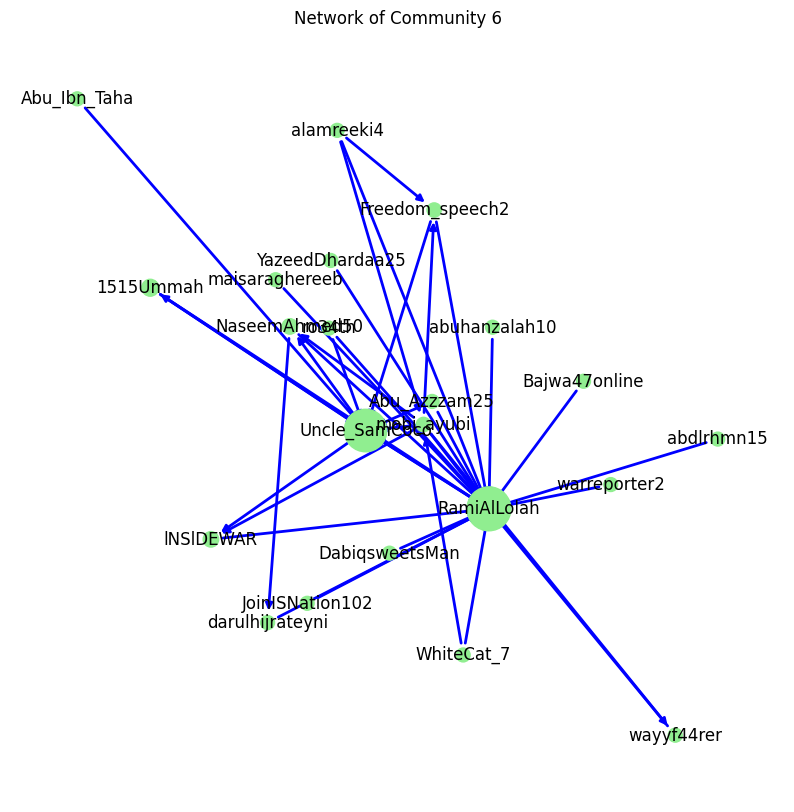

In [ ]:
max_pr6 = max(pr6.values())
min_pr6 = min(pr6.values())

node_size = [100 + (pr6[node] - min_pr6) / (max_pr6 - min_pr6) * 900 for node in G6.nodes]

pos = nx.spring_layout(G6)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G6, pos, node_color='lightgreen', node_size=node_size)
nx.draw_networkx_edges(G6, pos, edge_color='blue', width=2)
nx.draw_networkx_labels(G6, pos, font_size=12, font_color='black')

plt.title("Network of Community 6")
plt.axis('off')
plt.show()

In [ ]:
wcl6 = merged_df[merged_df['username'].isin(communities[5])]
wcl6 = wcl6[["username", "links", "doc_length"]]
avg = np.vstack([wcl6, ["Averages", np.trunc(wcl6["links"].mean()*1000)/1000, np.trunc(wcl6["doc_length"].mean())]])
wcl6 = pd.DataFrame(avg, columns= wcl6.columns)
wcl6

,username,links,doc_length
0,1515Ummah,0.657143,6654
1,RamiAlLolah,0.467337,128119
2,Uncle_SamCoco,0.488679,84856
3,Abu_Azzzam25,0.946809,9116
4,Abu_Ibn_Taha,1.0,1626
5,Bajwa47online,0.5,5790
6,DabiqsweetsMan,0.733333,1052
7,Freedom_speech2,0.414634,7666
8,NaseemAhmed50,1.074733,25567
9,JoinISNation102,1.214286,2432


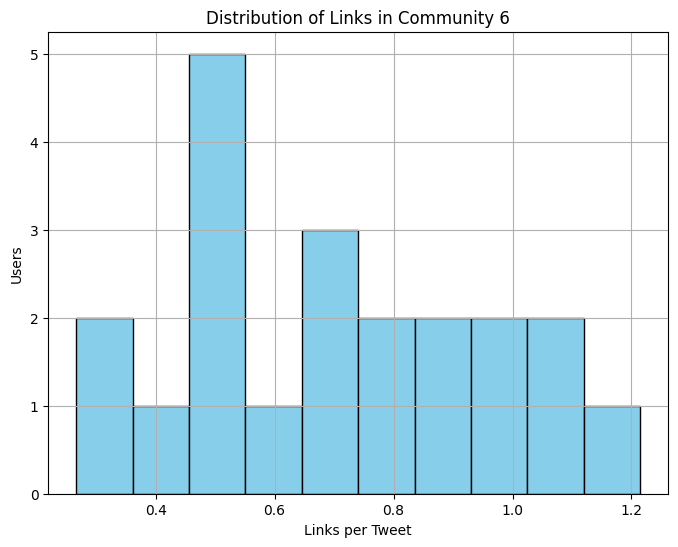

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl6['links'][:21]), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Links in Community 6')
plt.xlabel('Links per Tweet')
plt.ylabel('Users')
plt.grid(True)
plt.show()

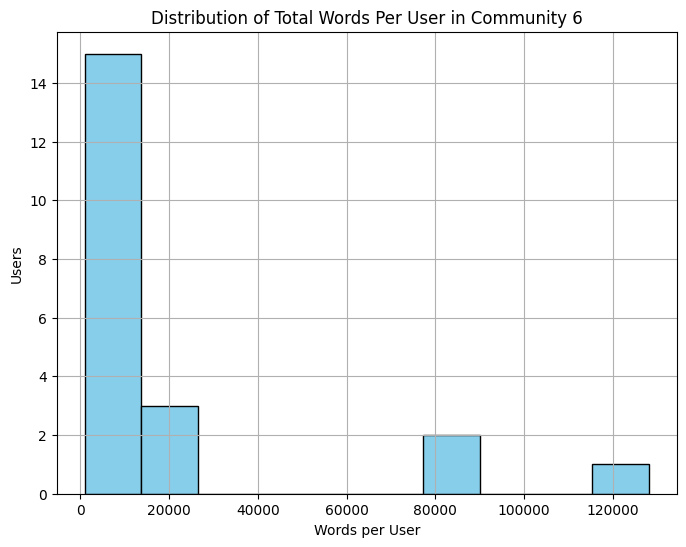

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(wcl6['doc_length'][:21]), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Words Per User in Community 6')
plt.xlabel('Words per User')
plt.ylabel('Users')
plt.grid(True)
plt.show()

In [ ]:
loc = df[df['username'].isin(communities[6])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,Dar Al Kufr,1


In [ ]:
loc[loc["location"] == "Dar Al Kufr"]

,username,location
5775,baaqiya_01,Dar Al Kufr
5776,baaqiya_01,Dar Al Kufr
5822,baaqiya_01,Dar Al Kufr
5833,baaqiya_01,Dar Al Kufr
5834,baaqiya_01,Dar Al Kufr
5857,baaqiya_01,Dar Al Kufr
5858,baaqiya_01,Dar Al Kufr
5860,baaqiya_01,Dar Al Kufr
5865,baaqiya_01,Dar Al Kufr


Communities 7

In [ ]:
communities[6]

{'Alwala_bara',
 'AsimAbuMerjem',
 'FidaeeFulaani',
 'MaghrabiArabi',
 'ManKhalfahum',
 'MilkSheikh2',
 'QassamiMarwan',
 'abuhumayra4',
 'ansarakhilafa',
 'grezz10',
 'ks48a174031',
 'moustiklash'}

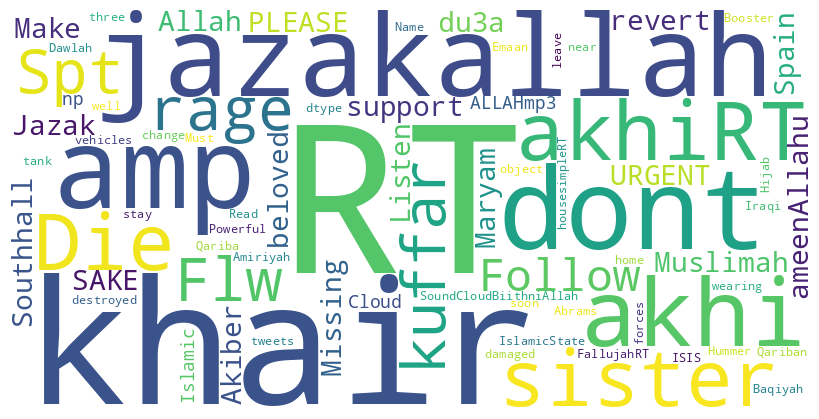

In [ ]:
com7 = merged_df[merged_df['username'].isin(communities[6])]
tweets_com7 = str(com7['tweets'])
tweets_com7 = tweets_com7.replace("\\n", "")
tweets_com7 = tweets_com7.replace(f"[{string.punctuation}]", "")
tweets_com7 = tweets_com7.replace("\\", "")
tweets_com7 = tweets_com7.replace("'", "")
tweets_com7 = tweets_com7.replace(".", "")
tweets_com7 = tweets_com7.replace(",", "")
tweets_com7 = re.sub(r'@\w+', '', tweets_com7)

comment_words = ''
stopwords = set(STOPWORDS)


wordcloud = WordCloud(stopwords=stopwords, width=800, height=400, background_color='white').generate(tweets_com7)


# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
com7

,username,tweets,links,pr,doc_length,clean_text
60,dieinurage29__7,"Follow and support our beloved akhi Jazak Allah khair ,RT @trenchstrategy2: URGENT!!!!!! PLEASE RT!!!! Missing Muslimah from Southhall!!!!! ,@dahmanijamal282 @aopyihg45 jazakallah khair akhi,@Hjrah_Jhad_13 jazakallah khair akhi,RT @PresosMusulmane: Make du3a for sister Maryam, 22, a revert of Spain. ,@haqseaker @PresosMusulmane ameen,Allahu Akiber ,RT @aboanfal000: Listen to FOR THE SAKE OF ALLAH.mp3 by Islamic Cloud #np on #SoundCloud\n,BiithniAllah that well change soon by #IS ,RT @baaqiya_01: Die in your rage, kuffar!! ,@baqiya120 jazakallah khair akhi,RT @1515Theory: Qariban Qariba #IslamicState #Baqiyah #ISIS",0.666667,0.002217,624,follow support belov akhi jazak allah khair rt trenchstrategi urgent pleas rt miss muslimah southhal dahmanijam aopyihg jazakallah khair akhi hjrah_jhad_ jazakallah khair akhi rt presosmusulman make dua sister maryam revert spain haqseak presosmusulman ameen allahu akib rt aboanf listen sake allah mp islam cloud np soundcloud biithniallah well chang soon rt baaqiya_ die rage kuffar baqiya jazakallah khair akhi rt theori qariban qariba islamicst baqiyah isi
61,baaqiya_01,",Die in your rage, kuffar!! ,RT @zzahuwa: ,RT @sarahlee1429: Flw &amp; Spt: @Hurairah_12 @AlwaysMryam @baaqiya_01 @_AtTaubah3839 @UmmLina38 @atruaz22 @AbuAnasheed @AnakSabil9,RT @sarahlee1429: Flw &amp; Spt:@baqiya120 @AISHA2981 @Hjrah_Jhad_13 @iislamic69 @sdfh734,RT @muslim3un: Sisters who don't like wearing Hijab don't have to, just stay home and don't leave the house..simple,RT @mustafaklash56: Dawlah damaged a Abrams tank &amp; destroyed three Hummer vehicles of Iraqi forces near Amiriyah Fallujah.,,RT @scholarsofhaq10: Powerful Emaan Booster! Must Read",0.555556,0.004101,568,die rage kuffar rt zzahuwa rt sarahle flw amp spt hurairah_ alwaysmryam baaqiya_ _attaubah ummlina atruaz abuanashe anaksabil rt sarahle flw amp spt baqiya aisha hjrah_jhad_ iislam sdfh rt muslimun sister like wear hijab stay home leav hous simpl rt mustafaklash dawlah damag abram tank amp destroy three hummer vehicl iraqi forc near amiriyah fallujah rt scholarsofhaq power emaan booster must read


In [ ]:
loc = df[df['username'].isin(communities[6])][["username","location"]]
loc.pivot_table(index='location', values='username', aggfunc=pd.Series.nunique).reset_index()

,location,username
0,Dar Al Kufr,1


## Average Community Statistics

In [ ]:
average_degree = [sum(dict(G2.degree()).values())/len(G2.degree()), sum(dict(G3.degree()).values())/len(G3.degree()), sum(dict(G4.degree()).values())/len(G4.degree()), sum(dict(G5.degree()).values())/len(G5.degree()), sum(dict(G6.degree()).values())/len(G6.degree())]
average_clustering = [nx.average_clustering(G2), nx.average_clustering(G3), nx.average_clustering(G4), nx.average_clustering(G5), nx.average_clustering(G6)]
average_links = [[wcl2['links'].iloc[len(wcl2)-1]],[wcl3['links'].iloc[len(wcl3)-1]], [wcl4['links'].iloc[len(wcl4)-1]], [wcl5['links'].iloc[len(wcl5)-1]], [wcl6['links'].iloc[len(wcl6)-1]]]
average_words = [[wcl2['doc_length'].iloc[len(wcl2)-1]],[wcl3['doc_length'].iloc[len(wcl3)-1]], [wcl4['doc_length'].iloc[len(wcl4)-1]], [wcl5['doc_length'].iloc[len(wcl5)-1]], [wcl6['doc_length'].iloc[len(wcl6)-1]]]

community_statistics = pd.DataFrame({
    "Avg Degree": average_degree,
    "Avg Clustering Coefficient": average_clustering,
    "Avg Links": average_links,
    "Avg Words": average_words
})
community_statistics.index += 1
community_statistics

,Avg Degree,Avg Clustering Coefficient,Avg Links,Avg Words
1,2.615385,0.024326,[0.573],[9837.0]
2,3.000000,0.194444,[0.51],[18404.0]
3,4.272727,0.235113,[0.664],[13642.0]
4,2.571429,0.103175,[0.561],[20831.0]
5,3.454545,0.319740,[0.695],[20535.0]


Jazakallah Khair
Kuffar
Beloved
Hijab, sister, qariba, akhi